# Processed GPS EDA

Claire Punturieri  
June 20, 2024

# Housekeeping

## Code Status

Complete to lab workflow standards as of 6/2024.

## Conclusions

EDA is conducted here using subjects with credible lapse reporting and at least one month of data (generated using mak_study_dates.qmd).

## Set up

## Environment

In [ ]:

options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true", 
                      sha1 = "a58e57da996d1b70bb9a5b58241325d6fd78890f")


### Paths

In [ ]:
path_shared <- format_path("studydata/risk/data_processed/shared")
path_gps <- format_path("studydata/risk/data_processed/gps")
path_maps <- format_path("studydata/risk/data_processed/gps/subject-maps")
#path_notes <- format_path("GitHub/analysis_risk/shared/notes")


## Packages and plot settings

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service/>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles/>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.

Loading required package: sp

## Examine individual participant data

### Load in data

In [ ]:
gps <- read_csv(here::here(path_shared, "gps.csv"), show_col_types = FALSE) |>
  relocate(subid)  |>
  mutate(date_central = date(time)) |> 
  glimpse()


Rows: 1,240,941
Columns: 13
$ subid           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ lat             <dbl> 43.07284, 43.07284, 43.07284, 43.07284, 43.07284, 43.0…
$ lon             <dbl> -89.40627, -89.40627, -89.40627, -89.40627, -89.40627,…
$ time            <dttm> 2017-03-01 15:47:24, 2017-03-01 18:03:11, 2017-03-01 …
$ accuracy        <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ sgmnt_type      <chr> "place", "place", "place", "place", "place", "move", "…
$ trckpnt_type    <chr> "unknown", "walking", "walking", "walking", "unknown",…
$ app_source      <chr> "moves", "moves", "moves", "moves", "moves", "moves", …
$ data_type       <chr> "gps", "gps", "gps", "gps", "gps", "gps", "gps", "gps"…
$ speed_kmh       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ altitude_meters <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ direction       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ date_centr

Rows: 151
Columns: 7
$ subid       <dbl> 1, 2, 3, 5, 6, 7, 9, 10, 11, 15, 16, 18, 19, 20, 21, 23, 2…
$ study_start <dttm> 2017-03-02 06:00:00, 2017-03-24 05:00:00, 2017-03-22 05:0…
$ data_start  <dttm> 2017-03-02 06:00:00, 2017-03-24 05:00:00, 2017-03-22 05:0…
$ study_end   <dttm> 2017-05-31 05:00:00, 2017-06-16 05:00:00, 2017-06-20 05:0…
$ ema_end     <dttm> 2017-05-30 16:10:53, 2017-06-16 14:18:40, 2017-06-20 02:0…
$ start_gps   <dttm> 2017-03-01 15:47:24, 2017-03-23 21:00:23, 2017-03-21 20:1…
$ end_gps     <dttm> 2017-06-05 13:14:59, 2017-04-25 02:12:35, 2017-06-21 23:1…

### Filter subjects with minimum amount of data

Pull list of subject IDs with at least one month data and credible lapse reporting.

In [ ]:
subids_dates <- study_dates |>  
  pull(subid) |>  
  unique()


Filter out subjects not included in study_dates.

In [ ]:
gps <-  gps |>  
  filter(subid %in% subids_dates)


### Count number of observations, including missing days

Count n_obs per day by subject – this will only count days for which participants have at least one data point.

In [ ]:
gps_obs <- gps |>
  mutate(date_central = date(time)) |> 
  group_by(subid, date_central) |>  
  summarise(n_obs = n())


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

Create data frame listing out all dates each subject was on study and should have had data.

In [ ]:
dates_long <- study_dates |> 
  select(subid, study_start, study_end) |> 
  pivot_longer(cols = starts_with("study"), names_to = "point", values_to = "time") |> 
  mutate(date_central = date(time)) |> 
  group_by(subid) |>
  complete(date_central=full_seq(date_central,1),fill=list(dummy=0)) |> 
  select(-time)


Merge with gps_obs. This will create “blank” days for days when subjects were on study but no data points were collected, which we can then fill in with 0s.

> Here I think we want to left_join because we only care about data points that are in the study_dates start and end range (sometimes GPS data was collected pre- and post-study, but that’s not relevant to us).

In [ ]:
gps_obs <- left_join(dates_long |> select(-point), gps_obs, by = c("subid", "date_central")) |> 
  mutate(n_obs = if_else(is.na(n_obs), 0, n_obs))


### Add in missing observations into raw GPS dataframe.

> Leaving this blank for now because I’m not sure if we need to do this for EDA? Would we want to do this for the raw GPS dataframe?

### Number of observations per person

Display histogram of \# observations per subject.

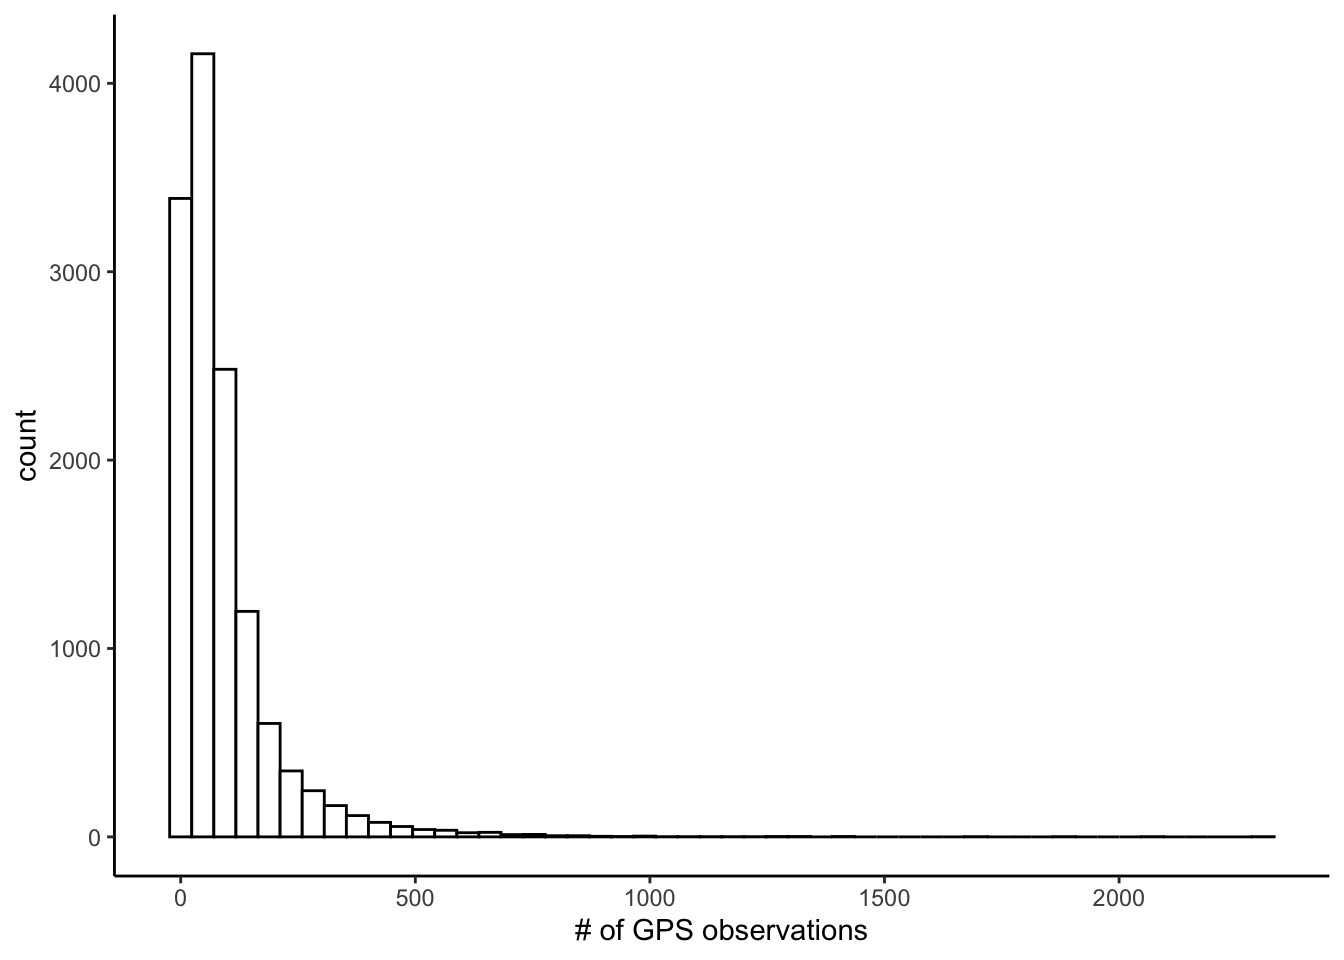

In [ ]:
gps_obs |>  
  group_by(subid) |>  
  ggplot(aes(x = n_obs)) +
  geom_histogram(bins = 50, color = "black", fill = "white") +
  xlab("# of GPS observations")


Create std_obs, a scaled version of n_obs based on total number of observations and days on study per subject.

In [ ]:
gps_obs <- gps_obs |>
  mutate(total_obs = sum(n_obs),
         total_days = as.numeric(last(date_central) - first(date_central)),
         std_obs = total_obs/total_days)


Display histogram of \# observations per subject on same scale.

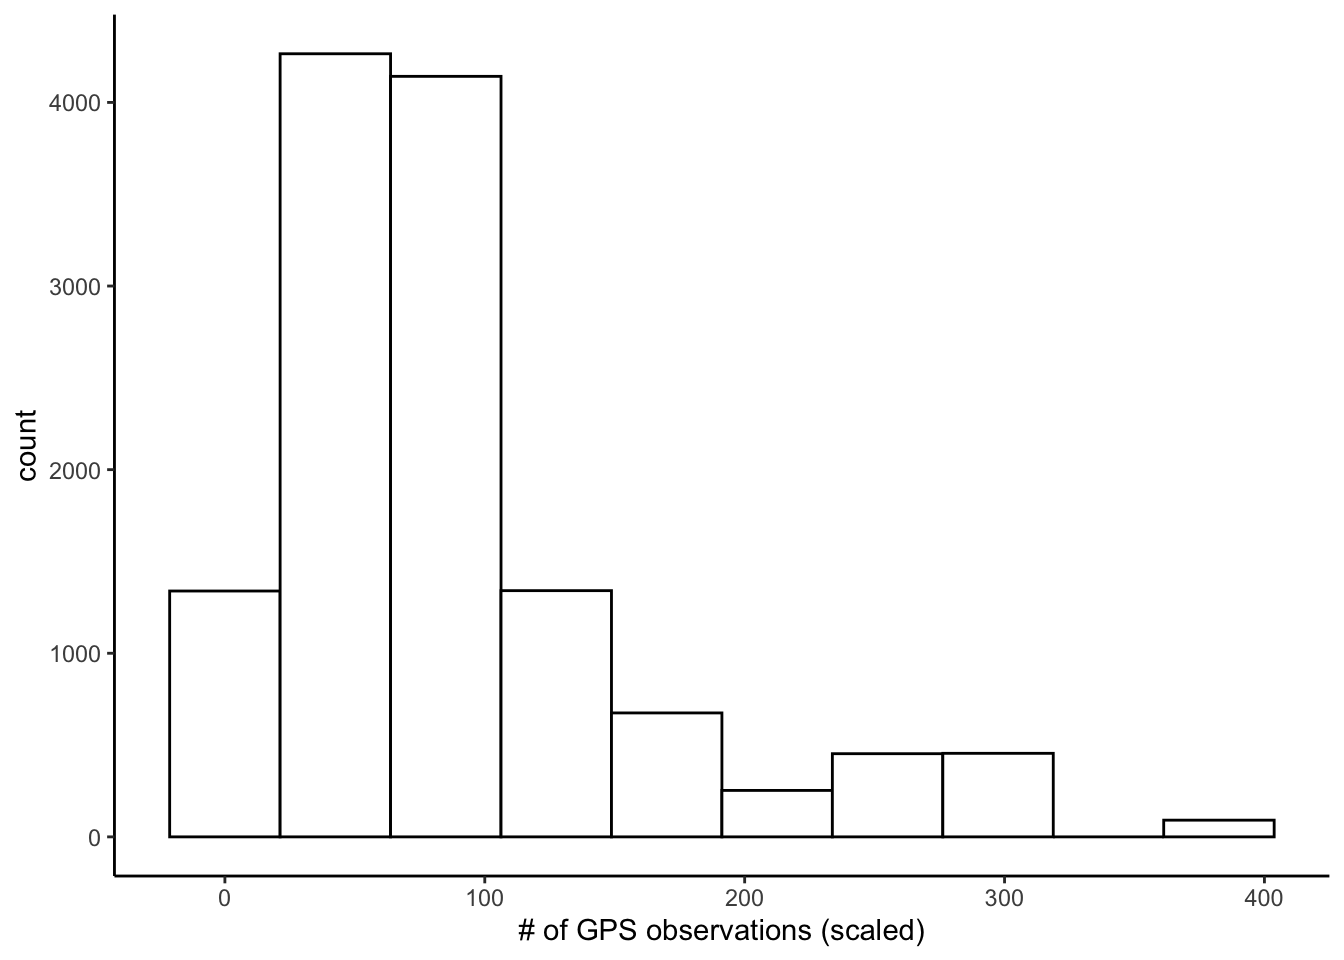

# A tibble: 1 × 4
# Groups:   subid [1]
  subid total_obs total_days std_obs
  <dbl>     <dbl>      <dbl>   <dbl>
1     5     34461         90    383.

In [ ]:
gps_obs |>  
  group_by(subid) |>  
  ggplot(aes(x = std_obs)) +
  geom_histogram(bins = 10, color = "black", fill = "white") +
  xlab("# of GPS observations (scaled)")


### Number of observations per day

**Calculated with missing days included.**

Subset data frame to display average observations per day, SD, minimum observation, and maximum observation per subject.

In [ ]:
obs_per_day <- gps_obs |>
  group_by(subid) |>  
  summarise(avg_obs_per_day = mean(n_obs),
            sd = sd(n_obs),
            min = min(n_obs),
            max = max(n_obs)) 


Display minimum average observation per day and maximum average observation per day across subjects.

In [ ]:
min(obs_per_day$avg_obs_per_day)


[1] 0.4

[1] 378.6923

Display minimum observations per day and maximum observations per day across subjects.

In [ ]:
min(obs_per_day$min)


[1] 0

[1] 2307

Display average observations per day across all subjects (average of average observations per day).

In [ ]:
mean(obs_per_day$avg_obs_per_day)


[1] 88.07377

Histogram of standard deviations (to look at high and low variance subjects).

> Consider filtering out data points that are a certain \# of SDs above a participant’s average number of points? Alternatively, could we think of using this as a feature?

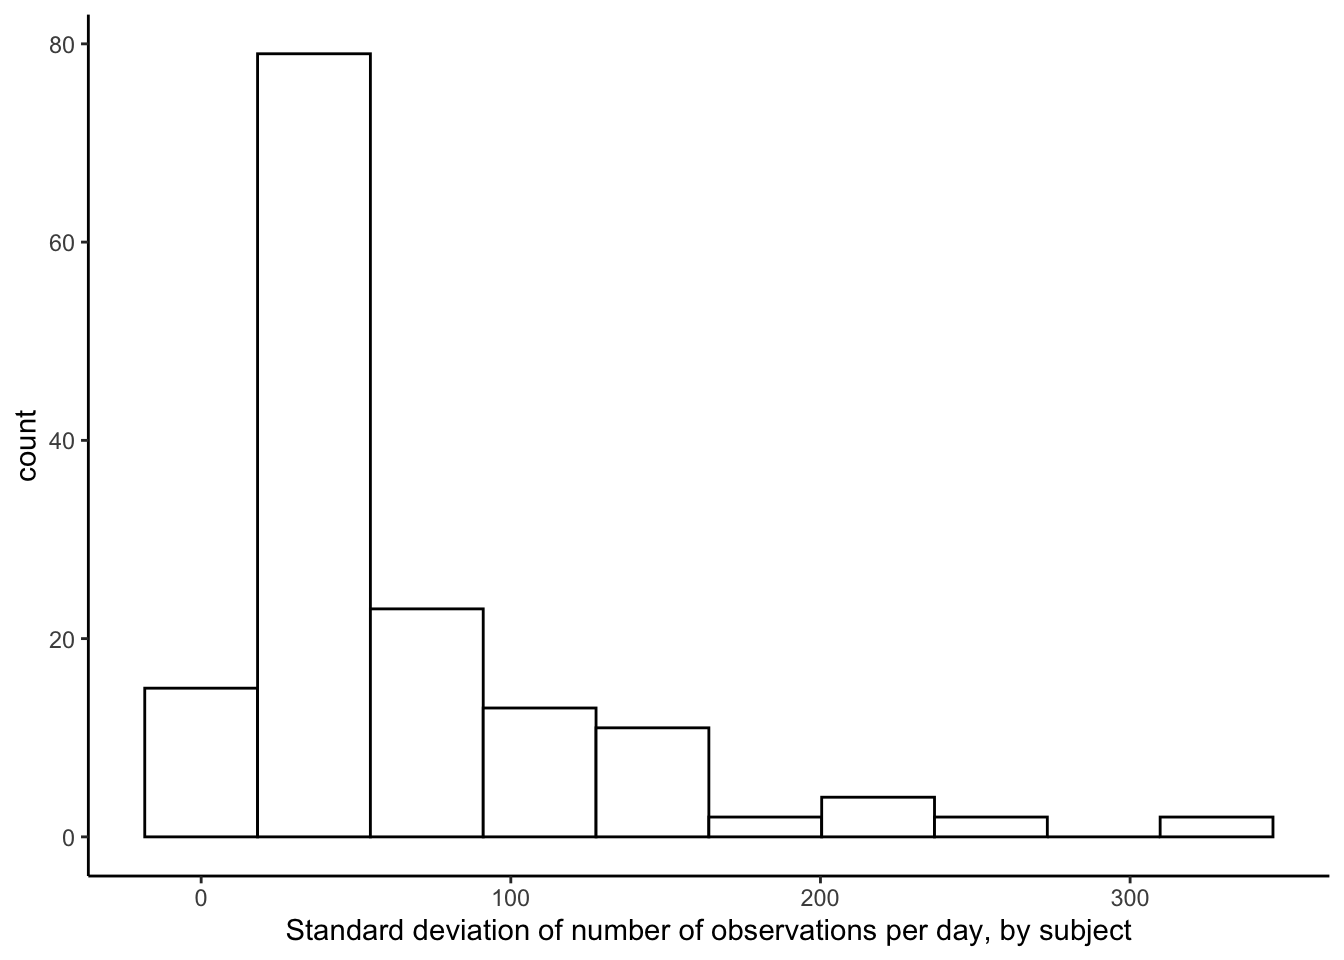

# A tibble: 2 × 3
  subid avg_obs_per_day    sd
  <dbl>           <dbl> <dbl>
1    38            255.  327.
2    44            272.  330.

In [ ]:
obs_per_day |>  
  ggplot(aes(x = sd)) +
  geom_histogram(bins = 10, color = "black", fill = "white") +
  xlab("Standard deviation of number of observations per day, by subject")


### Display number of observations by day per subject

In [ ]:
gps_obs |> 
  group_by(subid) |>
  print_kbl() |> 
  scroll_box(width = "700px", height = "200px")


### Plot number of observations by day per subject

Create timeseries plotting function.

In [ ]:
plot_timeseries <- function(x, y, z) {
    #gps_obs <- gps_obs |> filter(subid == z)
    gps_obs <- gps_obs |> filter(subid == z)
    
    graph_title <- paste0("Subject ID", z, sep = " ")
  
    #ggplot(data = gps_obs, aes(x = .data[[x]], y = .data[[y]], color = z)
    print(ggplot(data = gps_obs, aes(x = .data[[x]], y = .data[[y]], color = z)) +
          geom_line(color = "darkblue")) +
      labs(title = graph_title) +
      geom_hline(aes(yintercept = mean(n_obs), color = "red"), linetype = 2, show.legend = FALSE)
}


Get list of subjects.

In [ ]:
subid_all <- list(gps_obs$subid) |> unlist() |> unique()


If pdf output file does not already exist, create and save out plots in /data_processed/gps/subject-maps.

In [ ]:
if(file.exists(here::here(path_maps, "per-subj-timeseries.pdf"))){

  message("PDF file already exist -- delete to recreate!")

} else{
  timeseries_plots <- subid_all |>
    map(\(subid) plot_timeseries("date_central", "n_obs", subid))
    #map(\(subid) plot_timeseries("date_central", "n_obs", subid))
  
  output_file <- paste0(path_maps, "/per-subj-timeseries.pdf", sep = "")

  multi.page <- ggpubr::ggarrange(plotlist = timeseries_plots,
                                  nrow = 3, ncol = 1)
  ggpubr::ggexport(multi.page, filename = output_file)
}


PDF file already exist -- delete to recreate!

### Examine 1-observation days

Filter on days that have only one observation, sorting ascending on time to ensure that the individual points on these days are not all occurring around midnight (which would suggest spurious bursts of activity not actually related to the participant).

In [ ]:
full_join(gps, gps_obs, by=c("subid", "date_central")) |> 
  select(subid, lat, lon, time, n_obs) |> 
  filter(n_obs == 1) |>
  separate_wider_delim(time, delim = " ", names = c("date", "time")) |> 
  arrange(time) |> 
  kable(caption = "1-observation days") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


### Compare start and end dates

Extract first and last dates in GPS data per subject.

In [ ]:
gps_dates <- gps |>
  group_by(subid) |> 
  arrange(date_central) |> 
  slice(1, n()) |>
  mutate(start_study_gps = first(date_central),
         end_study_gps = last(date_central)) |> 
  select(subid, start_study_gps, end_study_gps) |> 
  distinct()


Extract start and end study dates from visit_dates.

In [ ]:
study_dates <- study_dates |>
  select(subid, study_start, study_end) |> 
  mutate(start_study_record = date(study_start),
         end_study_record = date(study_end)) |> 
  select(-study_start, -study_end)


Combine data frames.

In [ ]:
merge_dates <- left_join(gps_dates, study_dates)


Joining with `by = join_by(subid)`

Display comparison table of start and end dates.

In [ ]:
merge_dates |>
  kable(caption = "Comparison of start and end study dates based on staff records and GPS data collection") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate differences between date start and GPS start.

In [ ]:
merge_dates |>
  mutate(diff = start_study_record - start_study_gps) |>
  select(-end_study_record, -end_study_gps) |> 
  arrange(desc(diff)) |> 
  kable(caption = "Differences between study start and GPS start") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate differences between date end and GPS end.

> GPS collection ending after the end of study doesn’t matter because we won’t be using that data in any case.

In [ ]:
merge_dates |>
  mutate(diff = end_study_record - end_study_gps) |>
  select(-start_study_record, -start_study_gps) |> 
  arrange(diff) |> 
  kable(caption = "Differences between study end and GPS end") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate number of days on study.

> Already calculated above to standardize our \# of GPS observations, but maybe useful to look at in a table?

In [ ]:
merge_dates |>
  mutate(diff = end_study_record - start_study_record) |>
  select(-start_study_gps, -end_study_gps) |> 
  arrange(diff) |> 
  kable(caption = "Number of days on study") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


## GPS maps

Other map options we might be interested in generating for QC are interactive ones where you can move around (see Figure 1: https://journals.sagepub.com/doi/full/10.1177/25152459221082680).

### Static

Create function to generate static map per subject.

In [ ]:
plot_geo <- function(z) {
    gps <- gps |> filter(subid == z)
    
    graph_title <- paste0("Subject ID", z, sep = " ")
   
    cbbox <- make_bbox(lon = gps$lon, lat = gps$lat, f = .1)
    sq_map <- get_map(location = cbbox, maptype = "stamen_toner_lite")
    
    ggmap(sq_map) + 
      geom_path(data = gps, aes(x = gps$lon, y = gps$lat), 
                size = 1, lineend = "round", color="darkred") +
      labs(x = " ", y = " ", title = graph_title) +
      theme_minimal() +
      theme(legend.position = "none")
}


Generate subject ID list.

In [ ]:
subid_all <- list(gps$subid) |> unlist() |> unique()


Generate individual GPS map per subject and save out in /shared/gps/subject-maps if compiled file does already not exist.

In [ ]:

if(file.exists(here::here(path_gps, "per-subj-geo.pdf"))){

  message("PDF file already exist -- delete to recreate!")

} else{
  geo_plots <- subid_all |> 
    map(\(subid) plot_geo(subid))
  
  output_file <- paste0(path_gps, "/per-subj-geo.pdf", sep = "")

  multi.page <- ggpubr::ggarrange(plotlist = geo_plots,
                                    nrow = 1, ncol = 1)

  ggpubr::ggexport(multi.page, filename = output_file)
}


### Dynamic

Create gifs displaying participant movement during study duration. Note: this takes a *long* time to run – recommend subsetting data for a particular subject as opposed to generating map for entire duration on study.

In [ ]:

gps_mini <- gps |> filter(subid == "1" & time < "2017-03-02 16:07:24")

gps_mini <- gps_mini[!duplicated(gps_mini$time),]

gps_mini_moves <- df2move(gps_mini,
        proj = "+init=epsg:4326 +proj=longlat +datum=WGS84 +no_defs +ellps=WGS84 +towgs84=0,0,0", 
        x = "lon", y = "lat", time = "time", track_id = "subid")

# align move_data to a uniform time scale
m <- align_move(gps_mini_moves, res = 4, unit = "mins")


frames <- frames_spatial(m, path_colours = c("darkred"),
                         map_service = "osm", map_type = "streets",
                         alpha = 0.5) |>  
  add_labels(x = "Longitude", y = "Latitude") |>
  add_northarrow() |>  
  add_scalebar() |> 
  add_timestamps(type = "label") |>  
  add_progress()

frames[[10]] # preview frame

# animate frames
animate_frames(frames, out_file = "moveVis.gif")
